In [35]:
import sys
import subprocess

# Only install requirements if running in Google Colab
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', 'https://raw.githubusercontent.com/TheHardy04/IDS-ML/refs/heads/main/requirements.txt'])

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import time


In [37]:

# load dataset
# fetch dataset
rt_iot2022 = fetch_ucirepo(id=942)

# data (as pandas dataframes)
X = rt_iot2022.data.features
y = rt_iot2022.data.targets

In [38]:
print("--- Shape ---")
print(X.shape)

print("\n--- Info ---")
X.info()

print("\n--- Description ---")
display(X.describe())

print("\n--- Head ---")
display(X.head())

--- Shape ---
(123117, 83)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 83 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  object 
 3   service                   123117 non-null  object 
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio             123117 non-null  float64
 13  fwd

,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,1.231170e+05,1.231170e+05,1.231170e+05,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,123117.000000
mean,34639.258738,1014.305092,3.809566,2.268826,1.909509,1.471218,0.820260,3.518063e+05,3.517620e+05,7.035683e+05,...,1.481354e+05,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905123,2739.776018,751.647514
std,19070.620354,5256.371994,130.005408,22.336565,33.018311,19.635196,32.293948,3.707645e+05,3.708015e+05,7.415634e+05,...,1.613007e+06,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.313861,10018.848534,6310.183843
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,17702.000000,21.000000,0.000001,1.000000,1.000000,1.000000,0.000000,7.454354e+01,7.288927e+01,1.490871e+02,...,9.536740e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
50%,37221.000000,21.000000,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,2.467238e+05,4.934475e+05,...,4.053116e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
75%,50971.000000,21.000000,0.000005,1.000000,1.000000,1.000000,0.000000,5.242880e+05,5.242880e+05,1.048576e+06,...,5.006790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
max,65535.000000,65389.000000,21728.335580,4345.000000,10112.000000,4345.000000,10105.000000,1.048576e+06,1.048576e+06,2.097152e+06,...,4.374931e+08,4.774862e+08,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000000,65535.000000,65535.000000



--- Head ---


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,2282414.913,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,2028306.961,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,2281903.982,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,2047288.179,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,2087656.975,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502


In [39]:
# Drop columns containing specific substrings
bad_subs = ['min', 'max', 'tot', 'avg', 'std']
cols_to_drop = [c for c in X.columns if any(sub in c.lower() for sub in bad_subs)]

print(f"Dropping {len(cols_to_drop)} columns: {cols_to_drop}")
X = X.drop(columns=cols_to_drop)

Dropping 50 columns: ['fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.avg', 'fwd_iat.std', 'bwd_iat.min', 'bwd_iat.max', 'bwd_iat.tot', 'bwd_iat.avg', 'bwd_iat.std', 'flow_iat.min', 'flow_iat.max', 'flow_iat.tot', 'flow_iat.avg', 'flow_iat.std', 'active.min', 'active.max', 'active.tot', 'active.avg', 'active.std', 'idle.min', 'idle.max', 'idle.tot', 'idle.avg', 'idle.std']


In [40]:
X.info()
X

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  object 
 3   service                   123117 non-null  object 
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_per_sec          123117 non-null  float64
 6   bwd_pkts_per_sec          123117 non-null  float64
 7   flow_pkts_per_sec         123117 non-null  float64
 8   down_up_ratio             123117 non-null  float64
 9   flow_FIN_flag_count       123117 non-null  int64  
 10  flow_SYN_flag_count       123117 non-null  int64  
 11  flow_RST_flag_count       123117 non-null  int64  
 12  fwd_PSH_flag_count        123117 non-null  int64  
 13  bwd_PSH_flag_count        123117 non-null  i

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,flow_FIN_flag_count,...,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,38667,1883,tcp,mqtt,32.011598,0.281148,0.156193,0.437341,0.555556,0,...,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,64240,26847,502
1,51143,1883,tcp,mqtt,31.883584,0.282277,0.156821,0.439097,0.555556,0,...,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,64240,26847,502
2,44761,1883,tcp,mqtt,32.124053,0.280164,0.155647,0.435811,0.555556,0,...,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,64240,26847,502
3,60893,1883,tcp,mqtt,31.961063,0.281593,0.156440,0.438033,0.555556,0,...,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,64240,26847,502
4,51087,1883,tcp,mqtt,31.902362,0.282111,0.156728,0.438839,0.555556,0,...,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,64240,26847,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,59247,63331,tcp,-,0.000006,167772.160000,167772.160000,335544.320000,1.000000,1,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024
123113,59247,64623,tcp,-,0.000007,144631.172400,144631.172400,289262.344800,1.000000,1,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024
123114,59247,64680,tcp,-,0.000006,167772.160000,167772.160000,335544.320000,1.000000,1,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024
123115,59247,65000,tcp,-,0.000006,167772.160000,167772.160000,335544.320000,1.000000,1,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024


In [41]:
y

,Attack_type
0,MQTT_Publish
1,MQTT_Publish
2,MQTT_Publish
3,MQTT_Publish
4,MQTT_Publish
...,...
123112,NMAP_XMAS_TREE_SCAN
123113,NMAP_XMAS_TREE_SCAN
123114,NMAP_XMAS_TREE_SCAN
123115,NMAP_XMAS_TREE_SCAN


In [42]:
X = X.select_dtypes(include=[np.number])

In [43]:

# Encode target variable for correlation calculation
y_encoded = y['Attack_type'].astype('category').cat.codes

# Calculate correlation of each feature with the encoded target
correlations = X.corrwith(y_encoded).abs().sort_values(ascending=False)

print("--- Top 10 Features Correlated with Target ---")
print(correlations.head(10))




--- Top 10 Features Correlated with Target ---
flow_FIN_flag_count         0.408962
fwd_URG_flag_count          0.324308
fwd_init_window_size        0.311407
id.resp_p                   0.305570
payload_bytes_per_second    0.296198
bwd_pkts_per_sec            0.251580
flow_pkts_per_sec           0.251550
fwd_pkts_per_sec            0.251517
fwd_subflow_pkts            0.243494
flow_RST_flag_count         0.232254
dtype: float64


C:\Users\theoh\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\theoh\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

# take only the Attack type column to avoid errors 
y_train = y_train["Attack_type"]

Training Shape: (61558, 31)
Testing Shape: (61559, 31)


Decision Tree Optimization

In [45]:
dt_param_dist = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [46]:
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_dist, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print("Best DT Params:", dt_grid.best_params_)
print("Best DT CV Score:", dt_grid.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best DT Params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
Best DT CV Score: 0.996393655304065


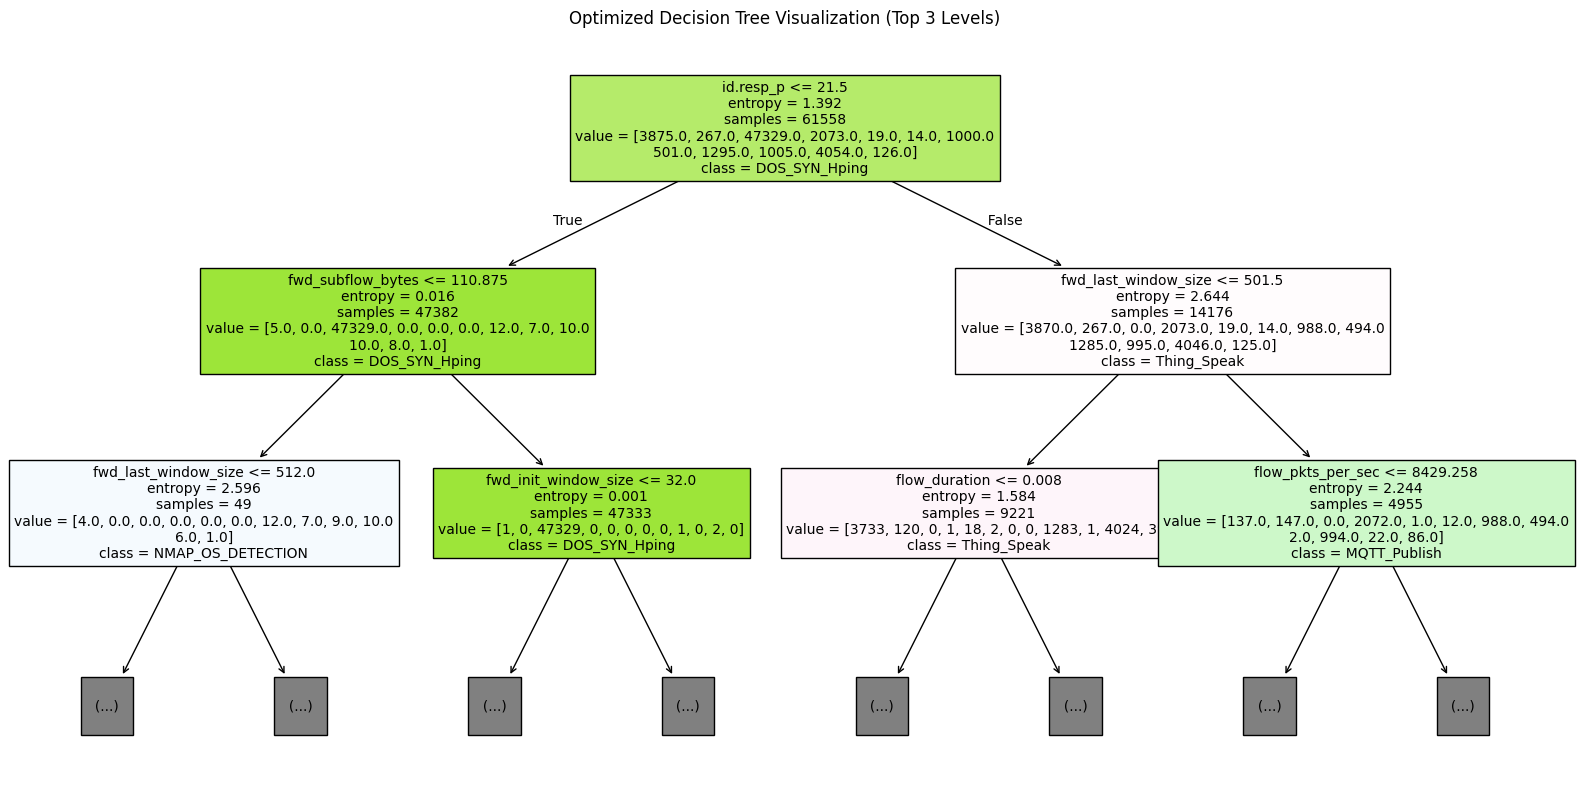

In [47]:
# plot the decision tree
plt.figure(figsize=(20,10))
plot_tree(
    best_dt,
    filled=True,
    feature_names=X.columns,
    class_names=best_dt.classes_,
    fontsize=10,
    max_depth=2  # Only show the top 2 levels
)
plt.title("Optimized Decision Tree Visualization (Top 3 Levels)")
plt.show()

SVM Optimization

In [48]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

In [49]:
svm_param_dist = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

In [50]:
# Speed up: Use a subset for hyperparameter tuning
# SVM scales quadratically/cubically, so full dataset tuning is very slow
sample_size = 15000 
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=sample_size, stratify=y_train, random_state=42
)


In [51]:
print(f"Tuning SVM on subset of {X_train_sub.shape[0]} samples...")

svm_random = RandomizedSearchCV(
    svm_pipeline, 
    param_distributions=svm_param_dist, 
    n_iter=10, 
    cv=2, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2,
    random_state=42
)
svm_random.fit(X_train_sub, y_train_sub)

best_svm_pipeline = svm_random.best_estimator_
print(f"Best SVM Params: {svm_random.best_params_}")
print(f"Best SVM CV Score: {svm_random.best_score_}")

Tuning SVM on subset of 15000 samples...
Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best SVM Params: {'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__C': 100}
Best SVM CV Score: 0.9847333333333333


Ensemble Methods

Bagging Decision Tree

In [52]:
bagging_dt = BaggingClassifier(
    estimator=best_dt,
    n_estimators=50,
    max_samples=0.8,
    random_state=42
)

In [53]:
bagging_dt.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,max_samples,0.8
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


Bagging SVM

In [54]:
bagging_svm = BaggingClassifier(
    estimator=best_svm_pipeline,
    n_estimators=5,     # Fewer estimators for SVM as it is slower
    max_samples=0.2,
    random_state=42
)


In [55]:
bagging_svm.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,n_estimators,5
,max_samples,0.2
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


Voting Classifier

In [56]:
voting_clf = VotingClassifier(
    estimators=[
        ('bagging_dt', bagging_dt),
        ('bagging_svm', bagging_svm)
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)

,estimators,"[('bagging_dt', ...), ('bagging_svm', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'entropy'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1


In [57]:
models = {
    "Optimized DT": best_dt,
    "Optimized SVM": best_svm_pipeline,
    "Bagging DT": bagging_dt,
    "Bagging SVM": bagging_svm,
    "Voting Soft": voting_clf
}

results = []

for name, model in models.items():
    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) * 1000 

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # Weighted for imbalance handling

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Inference Time (ms)": inference_time
    })

    print(f"-> {name} processed.")

# Create Comparison Table
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n", results_df)

-> Optimized DT processed.
-> Optimized SVM processed.
-> Bagging DT processed.
-> Bagging SVM processed.
-> Voting Soft processed.

            Model  Accuracy  F1-Score  Inference Time (ms)
2     Bagging DT  0.997742  0.997742           858.416796
0   Optimized DT  0.997141  0.997146            19.269466
4    Voting Soft  0.997108  0.997097         25874.492168
3    Bagging SVM  0.989668  0.989254         24850.064516
1  Optimized SVM  0.986923  0.986731          6161.970377
